In [1]:
import os
import math
import time
import random
import json
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from tqdm import tqdm

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.7.1+cu118
torchvision: 0.22.1+cu118


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {device}")

DATA_DIR = "./data"
EPOCHS = 20
BATCH_SIZE = 64

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs(os.path.join(ARTIFACT_DIR, "figures"), exist_ok=True)

DEVICE: cuda


In [3]:
weights = ResNet18_Weights.DEFAULT
print(weights)

ResNet18_Weights.IMAGENET1K_V1


In [4]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

IMG_SIZE = 224  

# NEW: transforms для SimpleCNN (базовые)
tf_train_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# NEW: transforms для SimpleCNN с аугментациями
tf_train_aug = transforms.Compose([
    transforms.RandomResizedCrop(size=96, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# transforms для ResNet
tf_train_resnet_aug = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

tf_eval_resnet = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# базовый eval transform (без аугментаций)
tf_eval_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [5]:
def load_STL10(data_dir :str = DATA_DIR, train_transform=None, eval_transform=None):
    if train_transform is None:
        train_transform = tf_train_base
    if eval_transform is None:
        eval_transform = tf_eval_base

    ds_train_aug = torchvision.datasets.STL10(root=data_dir, split="train", transform=train_transform, download=True)
    ds_train_eval = torchvision.datasets.STL10(root=data_dir, split="train", transform=eval_transform, download=True)
    ds_test = torchvision.datasets.STL10(root=data_dir, split="test", transform=eval_transform, download=True)
    return ds_train_aug, ds_train_eval, ds_test

class_names = torchvision.datasets.STL10(root=DATA_DIR, split="train", download=True).classes
print(f"Classes: {class_names}")

Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [6]:
def make_loaders(ds_train_aug, ds_train_eval, ds_test, val_ratio=0.2, random_seed=RANDOM_STATE, batch_size=BATCH_SIZE):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(random_seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val = Subset(ds_train_eval, val_idx)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

In [7]:
ds_train_aug, ds_train_eval, ds_test = load_STL10(train_transform=tf_train_base, eval_transform=tf_eval_base)
train_loader, val_loader, test_loader = make_loaders(ds_train_aug, ds_train_eval, ds_test)
x, y = next(iter(train_loader))
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

c:\Users\Karl\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:287: UserWarning: 
NVIDIA GeForce RTX 5060 Ti with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Ti GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


x shape: torch.Size([64, 3, 96, 96])
y shape: torch.Size([64])


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, output_size=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 96 -> 48
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 48 -> 24
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 24 -> 12
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 12 -> 6
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(6*6*128, 256),
            nn.ReLU(),
            nn.Linear(256, output_size),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:
with torch.no_grad():
    x0 = torch.randn(2, 3, 96, 96).to(device)
    y0 = SimpleCNN().to(device)(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 96, 96]) Output logits: torch.Size([2, 10])


In [10]:
from IPython.display import clear_output

def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs
    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs=5, verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in tqdm(range(1, epochs + 1)):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        dt = time.time() - t0
        if verbose:
            print(f"Epoch {epoch:02d}/{epochs} | train loss {tr_loss:.4f}, acc {tr_acc:.3f} | val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s")
        if not math.isfinite(tr_loss) or not math.isfinite(va_loss):
            print("NaN/Inf в loss – останавливаем обучение.")
            break
        clear_output()
    return history

def plot_history(hist, title="", save_path=None):
    epochs = list(range(1, len(hist["train_loss"]) + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(epochs, hist["train_loss"], label="train loss")
    ax1.plot(epochs, hist["val_loss"], label="val loss")
    ax1.set_xlabel("epochs")
    ax1.set_ylabel("loss")
    ax1.set_title(title + " | loss")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, hist["train_acc"], label="train accuracy")
    ax2.plot(epochs, hist["val_acc"], label="val accuracy")
    ax2.set_xlabel("epochs")
    ax2.set_ylabel("accuracy")
    ax2.set_title(title + " | accuracy")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [11]:
def run_experiment(train_loader, val_loader, test_loader, exp_id, model, epochs=EPOCHS, lr=1e-3, weight_decay=0.0, transform_desc=""):
    model = model.to(device) 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    print(f"\n{'='*80}")
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_trainable_params(model))
    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = max(hist["val_acc"])
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    return {
        "exp_id": exp_id,
        "model": model,
        "history": hist,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "trainable_params": count_trainable_params(model),
        "epochs_trained": len(hist["train_loss"]),
        "transform_desc": transform_desc,
    }

results = []

100%|██████████| 20/20 [03:35<00:00, 10.79s/it]


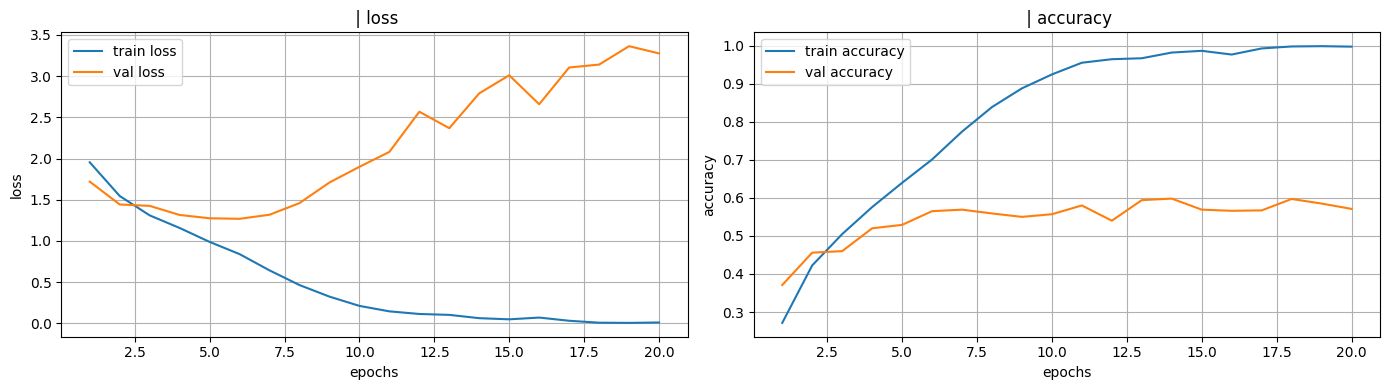

In [12]:
# C1: SimpleCNN без аугментаций
ds_train_aug, ds_train_eval, ds_test = load_STL10(train_transform=tf_train_base, eval_transform=tf_eval_base)
train_loader, val_loader, test_loader = make_loaders(ds_train_aug, ds_train_eval, ds_test)

model1 = SimpleCNN()
res1 = run_experiment(train_loader, val_loader,test_loader, "C1", model1, epochs=EPOCHS,
                      transform_desc="train: ToTensor+Normalize; val/test: ToTensor+Normalize")
results.append(res1)

plot_history(res1["history"])

100%|██████████| 20/20 [03:37<00:00, 10.86s/it]


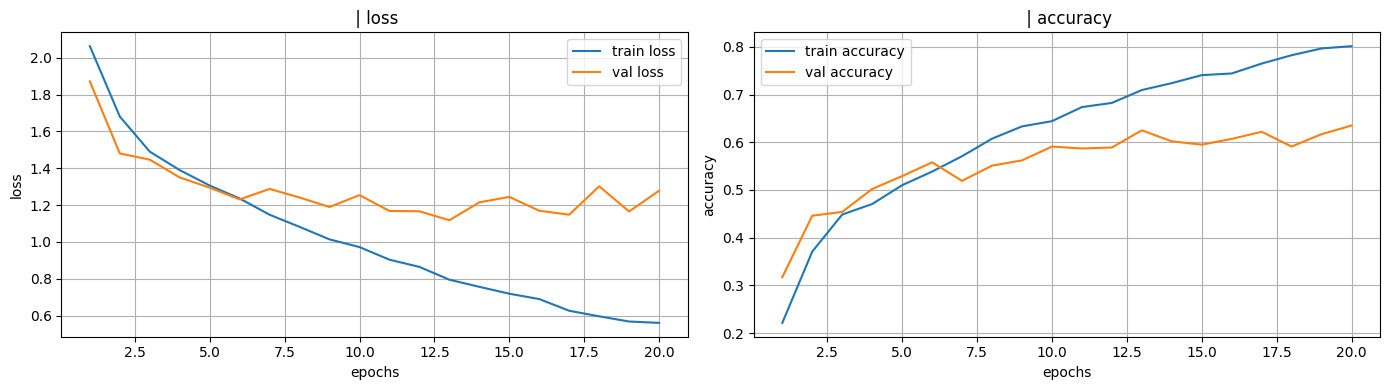

In [13]:
# C2: SimpleCNN с аугментациями
ds_train_aug, ds_train_eval, ds_test = load_STL10(train_transform=tf_train_aug, eval_transform=tf_eval_base)
train_loader, val_loader, test_loader = make_loaders(ds_train_aug, ds_train_eval, ds_test)
model2 = SimpleCNN()
res2 = run_experiment(train_loader, val_loader,test_loader, "C2", model2, epochs=EPOCHS,
                      transform_desc="train: RandomResizedCrop+RandomHorizontalFlip+ToTensor+Normalize; val/test: ToTensor+Normalize")
results.append(res2)

plot_history(res2["history"])

100%|██████████| 20/20 [04:20<00:00, 13.05s/it]


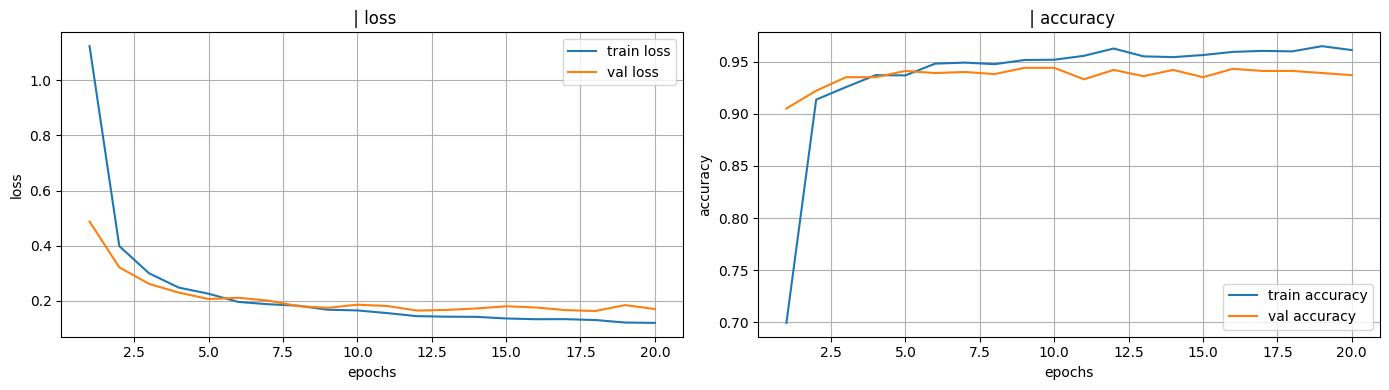

In [14]:
# C3: ResNet18 head-only
ds_train_aug, ds_train_eval, ds_test = load_STL10(train_transform=tf_train_resnet_aug, eval_transform=tf_eval_resnet)
train_loader, val_loader, test_loader = make_loaders(ds_train_aug, ds_train_eval, ds_test, batch_size=64)
def build_resnet18_head_only(num_classes=10):
    model = resnet18(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model
model3 = build_resnet18_head_only()
res3 = run_experiment(train_loader, val_loader,test_loader, "C3", model3, epochs=EPOCHS, lr=1e-3,
                      transform_desc="train: Resize+RandomResizedCrop+RandomHorizontalFlip+ToTensor+Normalize (ImageNet stats); val/test: Resize+CenterCrop+ToTensor+Normalize")
results.append(res3)

plot_history(res3["history"])

100%|██████████| 20/20 [04:21<00:00, 13.07s/it]


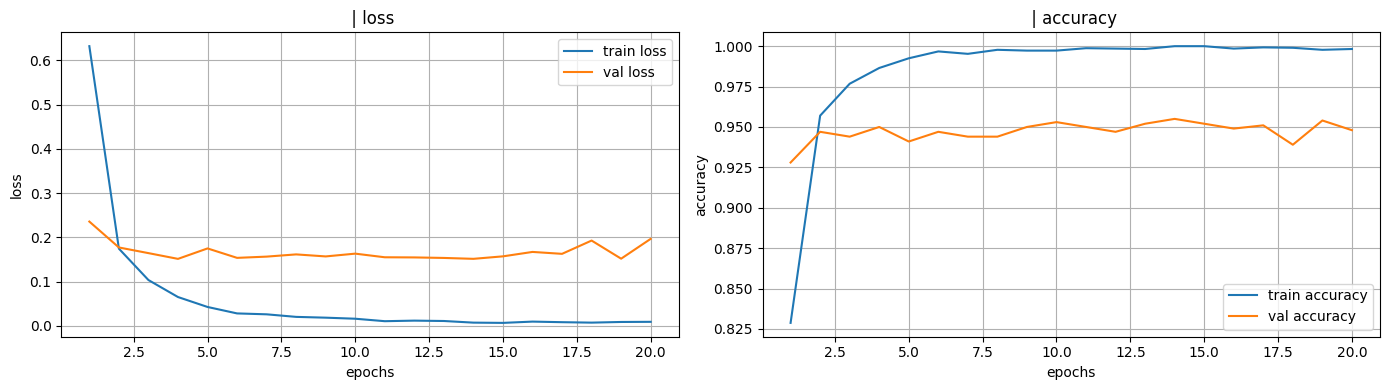

In [15]:
# C4: ResNet18 fine-tune (layer4 + fc)
def build_resnet18_finetune(num_classes=10):
    model = resnet18(weights=weights)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model4 = build_resnet18_finetune()
res4 = run_experiment(train_loader, val_loader, test_loader,"C4", model4, epochs=EPOCHS, lr=1e-4,
                      transform_desc=res3["transform_desc"])
results.append(res4)

plot_history(res4["history"])

In [16]:
import json
from pathlib import Path
torch.save(model4.state_dict(), os.path.join(ARTIFACT_DIR, "best_classifier.pt"))

results_for_save = results

def build_resnet18_finetune(num_classes=10):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
    return model
model = build_resnet18_finetune()
model.load_state_dict(torch.load(os.path.join(ARTIFACT_DIR, "best_classifier.pt")))
model = model.to(device)


criterion = torch.nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Final test accuracy: {test_acc:.4f}, test loss: {test_loss:.4f}")

Final test accuracy: 0.9446, test loss: 0.1973


In [ ]:
config = {
    "dataset": "STL10",
    "seed": 42,
    "architecture": "ResNet18",
    "augmentations": False,
    "pretrained": True,
    "fine_tune_strategy": "layer4+fc",
    "transforms": {
        "train": "resize_transform (Resize 224, ToTensor, ImageNet Normalize)",
        "val": "resize_transform (Resize 224, ToTensor, ImageNet Normalize)",
        "test": "resize_transform (Resize 224, ToTensor, ImageNet Normalize)"
    },
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "batch_size": 64,
    "num_epochs": 20
}

output_path = Path( os.path.join(ARTIFACT_DIR, "best_classifier_config.json"))
with output_path.open("w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print(f"Saved config to {output_path.resolve()}")

Saved config to D:\VSCode\ЦК\aie-student-template\homeworks\HW10-11\artifacts\best_classifier_config.json


In [18]:
df = pd.DataFrame([{
    "experiment_id": r["exp_id"],
    "task": "classification",
    "dataset": "STL10",
    "seed": RANDOM_STATE,
    "model_summary": type(r["model"]).__name__,
    "optimizer": "Adam",
    "lr": 1e-3 if r["exp_id"] in ["C1","C2","C3"] else 1e-4,
    "epochs_trained": r["epochs_trained"],
    "best_val_accuracy": r["best_val_acc"],
    "test_accuracy": r["test_acc"],
    "precision": None,
    "recall": None,
    "mean_iou": None,
    "notes": None
} for r in results])

csv_path = os.path.join(ARTIFACT_DIR, "runs.csv")
if os.path.exists(csv_path):
    existing = pd.read_csv(csv_path)
    df = pd.concat([existing, df], ignore_index=True)
df.to_csv(csv_path, index=False)
print(f"Saved runs to {csv_path}")

Saved runs to artifacts\runs.csv


C:\Users\Karl\AppData\Local\Temp\ipykernel_15060\2661850495.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([existing, df], ignore_index=True)


In [19]:
results_for_save = results

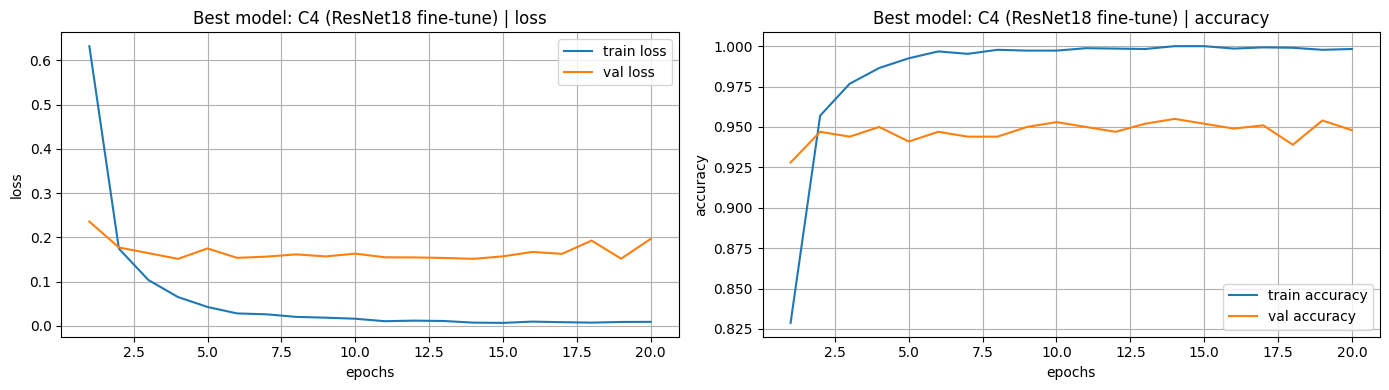

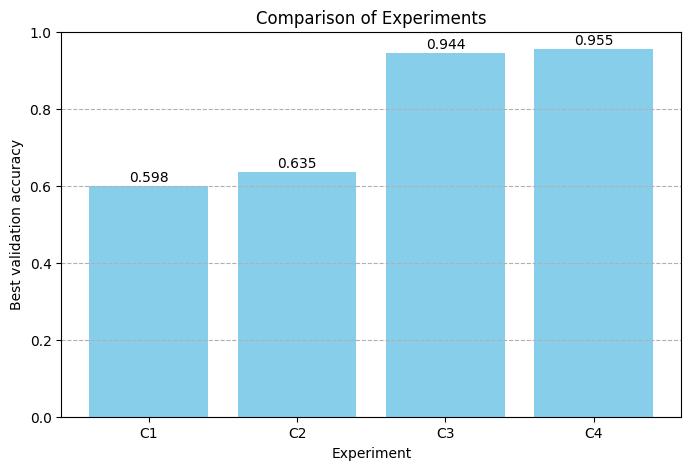

In [20]:
plot_history(res4["history"], title=f"Best model: C4 (ResNet18 fine-tune)", 
             save_path=os.path.join(ARTIFACT_DIR, "figures", "classification_curves_best.png"))

exp_names = [r["exp_id"] for r in results]
val_accs = [r["best_val_acc"] for r in results]
plt.figure(figsize=(8, 5))
plt.bar(exp_names, val_accs, color='skyblue')
plt.xlabel('Experiment')
plt.ylabel('Best validation accuracy')
plt.title('Comparison of Experiments')
for i, v in enumerate(val_accs):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', va='bottom')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--')
plt.savefig(os.path.join(ARTIFACT_DIR, "figures", "classification_compare.png"), bbox_inches="tight")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8952821..2.4110641].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.3760502].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..

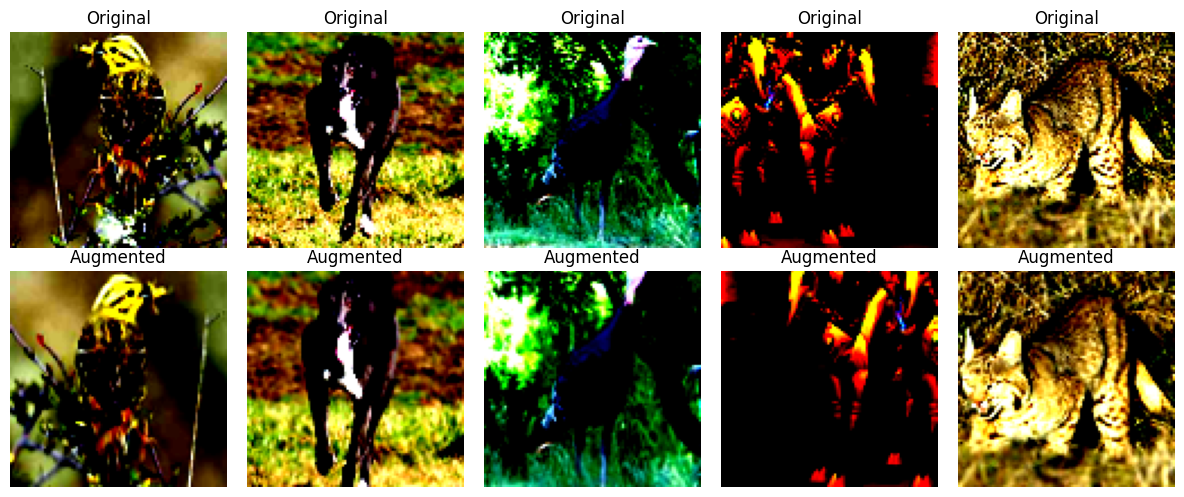

In [21]:
ds_plain, _, _ = load_STL10(train_transform=tf_train_base, eval_transform=tf_eval_base)
ds_aug, _, _ = load_STL10(train_transform=tf_train_aug, eval_transform=tf_eval_base)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    img_plain, _ = ds_plain[i]
    img_aug, _ = ds_aug[i]
    axes[0, i].imshow(img_plain.permute(1,2,0).numpy())
    axes[0, i].axis('off')
    axes[0, i].set_title('Original')
    axes[1, i].imshow(img_aug.permute(1,2,0).numpy())
    axes[1, i].axis('off')
    axes[1, i].set_title('Augmented')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "figures", "augmentations_preview.png"), bbox_inches="tight")
plt.show()

## Часть B. Детекция объектов (Pascal VOC, FasterRCNN)


In [ ]:
import torch
import torchvision
from torchvision import transforms as T
from torchvision.datasets import VOCDetection
from torchvision.ops import box_iou
import numpy as np
import matplotlib.pyplot as plt
import os

# Параметры
VOC_ROOT = 'data'  # путь для скачивания VOC
VOC_YEAR = '2007'
SCORE_THRESHOLDS = [0.3, 0.7]
ARTIFACTS_DIR = 'artifacts/'
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# Фиксируем seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Загрузка датасета Pascal VOC (тестовая часть)
dataset = VOCDetection(VOC_ROOT, year=VOC_YEAR, image_set='test', download=True)

# Загрузка предобученной модели FasterRCNN
try:
    from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)
except Exception:
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.to(device)
model.eval()
print(dataset[0])

(<PIL.Image.Image image mode=RGB size=353x500 at 0x22760CDD310>, {'annotation': {'folder': 'VOC2007', 'filename': '000001.jpg', 'source': {'database': 'The VOC2007 Database', 'annotation': 'PASCAL VOC2007', 'image': 'flickr', 'flickrid': '341012865'}, 'owner': {'flickrid': 'Fried Camels', 'name': 'Jinky the Fruit Bat'}, 'size': {'width': '353', 'height': '500', 'depth': '3'}, 'segmented': '0', 'object': [{'name': 'dog', 'pose': 'Left', 'truncated': '1', 'difficult': '0', 'bndbox': {'xmin': '48', 'ymin': '240', 'xmax': '195', 'ymax': '371'}}, {'name': 'person', 'pose': 'Left', 'truncated': '1', 'difficult': '0', 'bndbox': {'xmin': '8', 'ymin': '12', 'xmax': '352', 'ymax': '498'}}]}})


In [23]:
def voc_target_to_boxes(target):
    ann = target['annotation']
    objs = ann.get('object')
    if objs is None:
        return torch.zeros((0, 4), dtype=torch.float32)
    if isinstance(objs, dict):
        objs = [objs]
    boxes = []
    for o in objs:
        b = o['bndbox']
        xmin = float(b['xmin'])
        ymin = float(b['ymin'])
        xmax = float(b['xmax'])
        ymax = float(b['ymax'])
        boxes.append([xmin, ymin, xmax, ymax])
    return torch.tensor(boxes, dtype=torch.float32)

from PIL import ImageDraw

def visualize_predictions(img_pil, gt_boxes, pred_boxes, pred_scores, save_path=None, title=None):
    img = img_pil.copy()
    draw = ImageDraw.Draw(img)
    for b in gt_boxes:
        draw.rectangle(list(b), outline='green', width=2)
    for b, s in zip(pred_boxes, pred_scores):
        draw.rectangle(list(b), outline='red', width=2)
        draw.text((b[0], b[1]), f"{s:.2f}", fill='red')
    if title:
        img = np.array(img)
        plt.figure(figsize=(8,8))
        plt.imshow(img)
        plt.title(title)
        plt.axis('off')
        if save_path:
            plt.savefig(save_path, bbox_inches='tight')
            plt.close()
        else:
            plt.show()
    elif save_path:
        img.save(save_path)
    else:
        img.show()


In [ ]:
# Функция для вычисления экспериментов V1 и V2
def evaluate_detection(model, dataset, device, score_threshold=0.3, iou_match=0.5, limit=100, save_examples_path=None):
    import matplotlib.pyplot as plt
    transform = T.ToTensor()
    total_TP = 0
    total_FP = 0
    total_FN = 0
    matched_ious = []
    example_imgs = []
    example_titles = []
    for idx in range(len(dataset)):
        if limit and idx >= limit:
            break
        img, target = dataset[idx]
        img_tensor = transform(img).to(device)
        with torch.no_grad():
            outputs = model([img_tensor])
        out = outputs[0]
        pred_boxes = out['boxes'].cpu()
        scores = out['scores'].cpu()
        keep = scores >= score_threshold
        pred_boxes = pred_boxes[keep]
        scores = scores[keep]
        gt_boxes = voc_target_to_boxes(target)
        if gt_boxes.numel() == 0:
            total_FP += pred_boxes.shape[0]
            continue
        if pred_boxes.numel() == 0:
            total_FN += gt_boxes.shape[0]
            continue
        ious = box_iou(pred_boxes, gt_boxes)
        P, G = ious.shape
        ious_np = ious.numpy()
        matched_pred = set()
        matched_gt = set()
        pairs = []
        for p in range(P):
            for g in range(G):
                pairs.append((ious_np[p, g], p, g))
        pairs.sort(reverse=True, key=lambda x: x[0])
        for iou_val, p, g in pairs:
            if iou_val < iou_match:
                break
            if p in matched_pred or g in matched_gt:
                continue
            matched_pred.add(p)
            matched_gt.add(g)
            matched_ious.append(iou_val)
        TP = len(matched_pred)
        FP = P - TP
        FN = G - TP
        total_TP += TP
        total_FP += FP
        total_FN += FN
        if save_examples_path and len(example_imgs) < 4:
            from PIL import ImageDraw
            img_vis = img.copy()
            draw = ImageDraw.Draw(img_vis)
            for b in gt_boxes:
                draw.rectangle(list(b), outline='green', width=2)
            for b, s in zip(pred_boxes, scores):
                draw.rectangle(list(b), outline='red', width=2)
                draw.text((b[0], b[1]), f"{s:.2f}", fill='red')
            example_imgs.append(img_vis)
            example_titles.append(f"TP={TP} FP={FP} FN={FN}")
    precision = total_TP / (total_TP + total_FP) if (total_TP + total_FP) > 0 else 0.0
    recall = total_TP / (total_TP + total_FN) if (total_TP + total_FN) > 0 else 0.0
    mean_iou = float(np.mean(matched_ious)) if len(matched_ious) > 0 else 0.0
    if save_examples_path and example_imgs:
        fig, axes = plt.subplots(1, len(example_imgs), figsize=(5*len(example_imgs), 5))
        if len(example_imgs) == 1:
            axes = [axes]
        for ax, img, title in zip(axes, example_imgs, example_titles):
            ax.imshow(img)
            ax.set_title(title)
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(save_examples_path)
        plt.close(fig)
    return {
        'precision': precision,
        'recall': recall,
        'mean_iou': mean_iou,
        'TP': total_TP,
        'FP': total_FP,
        'FN': total_FN,
    }



=== Inference, threshold=0.3 ===
precision=0.2935 recall=0.8892 mean_iou=0.8043

=== Inference, threshold=0.7 ===
precision=0.5828 recall=0.7904 mean_iou=0.8107


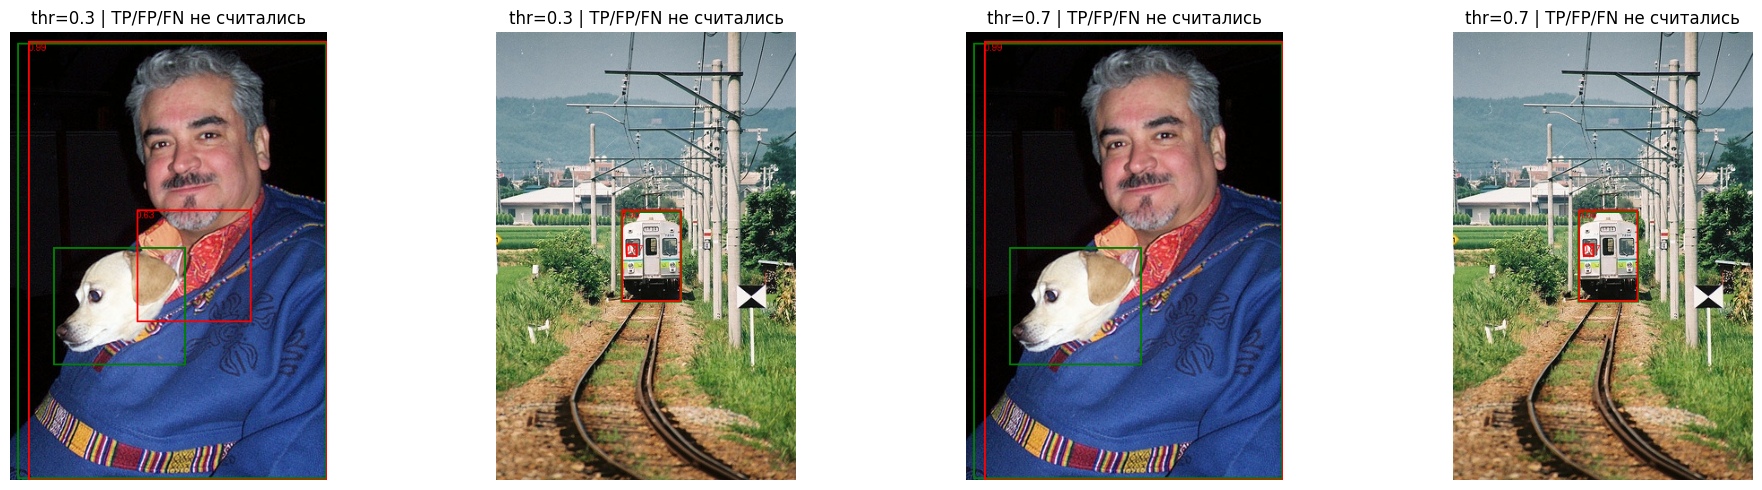

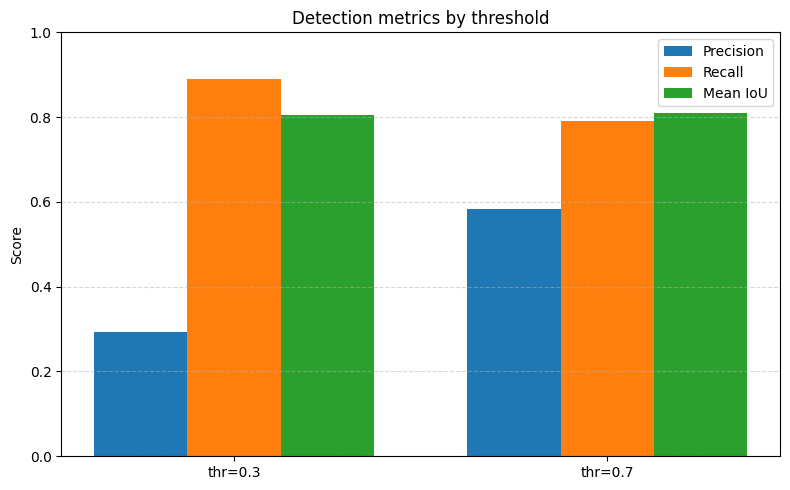

Сохранено: artifacts/runs.csv


In [ ]:
results = {}
example_imgs = []
example_titles = []
i=0
# THRESHOLDS для экспериментов V1 и V2
for thr in SCORE_THRESHOLDS:
    i+=1
    print(f'\n=== Inference, threshold={thr} ===')
    res = evaluate_detection(model, dataset, device, score_threshold=thr, iou_match=0.5, limit=100)
    print(f"precision={res['precision']:.4f} recall={res['recall']:.4f} mean_iou={res['mean_iou']:.4f}")
    results[f'V{i}'] = res
    transform = T.ToTensor()
    count = 0
    for idx in range(len(dataset)):
        if count >= 2:
            break
        img, target = dataset[idx]
        img_tensor = transform(img).to(device)
        with torch.no_grad():
            outputs = model([img_tensor])
        out = outputs[0]
        pred_boxes = out['boxes'].cpu()
        scores = out['scores'].cpu()
        keep = scores >= thr
        pred_boxes = pred_boxes[keep]
        scores = scores[keep]
        gt_boxes = voc_target_to_boxes(target)
        from PIL import ImageDraw
        img_vis = img.copy()
        draw = ImageDraw.Draw(img_vis)
        for b in gt_boxes:
            draw.rectangle(list(b), outline='green', width=2)
        for b, s in zip(pred_boxes, scores):
            draw.rectangle(list(b), outline='red', width=2)
            draw.text((b[0], b[1]), f"{s:.2f}", fill='red')
        example_imgs.append(img_vis)
        example_titles.append(f"thr={thr} | TP/FP/FN не считались")
        count += 1

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(example_imgs), figsize=(5*len(example_imgs), 5))
if len(example_imgs) == 1:
    axes = [axes]
for ax, img, title in zip(axes, example_imgs, example_titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'detection_examples.png'))
plt.show()
plt.close(fig)

import numpy as np
labels = [f"thr={thr}" for thr in SCORE_THRESHOLDS]
precisions = [results[f'V{int(thr)}']['precision'] for thr in range(1,len(SCORE_THRESHOLDS)+1)]
recalls = [results[f'V{int(thr)}']['recall'] for thr in range(1,len(SCORE_THRESHOLDS)+1)]
mean_ious = [results[f'V{int(thr)}']['mean_iou'] for thr in range(1,len(SCORE_THRESHOLDS)+1)]
x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width, precisions, width, label='Precision')
rects2 = ax.bar(x, recalls, width, label='Recall')
rects3 = ax.bar(x + width, mean_ious, width, label='Mean IoU')
ax.set_ylabel('Score')
ax.set_title('Detection metrics by threshold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'detection_metrics.png'))
plt.show()
plt.close(fig)
# Сохранение экспериментов V1 и V2
runs_csv = os.path.join(ARTIFACTS_DIR, 'runs.csv')
header = ['experiment_id','task','dataset','seed','model_summary','optimizer','lr','epochs_trained','best_val_accuracy',"test_accuracy",'precision','recall','mean_iou','notes']
if os.path.exists(runs_csv):
    with open(runs_csv, 'r', encoding='utf8') as f:
        lines = f.read().splitlines()
    if lines and lines[0].strip() == ','.join(header):
        existing = lines[1:]
    else:
        existing = lines
else:
    existing = []
new_lines = []
for tag, res in results.items():
    row = [tag, 'detection', f'PascalVOC{VOC_YEAR}', str(SEED), 'FasterRCNN_ResNet50_FPN(pretrained)', '', '', '', '', f"{res['precision']:.4f}", f"{res['recall']:.4f}", f"{res['mean_iou']:.4f}", 'inference-only']
    new_lines.append(','.join(row))
with open(runs_csv, 'w', encoding='utf8') as f:
    f.write(','.join(header) + '\n')
    for l in existing:
        if l.strip():
            f.write(l + '\n')
    for l in new_lines:
        f.write(l + '\n')
print('Сохранено:', runs_csv)
